In [1]:
import pandas as pd
import numpy as np
import glob

In [2]:
#cargar los csv
files = glob.glob("data/wyscout_csv/*.csv") 

files

['data/wyscout_csv\\Bundesliga_2024-25.csv',
 'data/wyscout_csv\\LaLiga_2024-25.csv',
 'data/wyscout_csv\\LigaPortugal.csv',
 'data/wyscout_csv\\Ligue1_2024-25.csv',
 'data/wyscout_csv\\Premier_2024-25.csv',
 'data/wyscout_csv\\SerieA_2024-25.csv']

In [3]:
df_list = []

for file in files:
    df = pd.read_csv(file)
    
    # añadimos nombre de liga (para saber de dónde viene)
    df["league"] = file.split("\\")[-1].split("_")[0]

    df["league"] = df["league"].replace({
    "Premier": "Premier League",
    "Ligue1": "Ligue 1", 
    "LigaPortugal.csv": "Liga Portuguesa", 
})
    
    df_list.append(df)

df = pd.concat(df_list, ignore_index=True)

In [4]:
df["positions"]

0             CF|LW
1          RAMF|AMF
2                RW
3                RW
4       RB|RWB|RCB3
           ...     
4232         CF|AMF
4233             GK
4234       DMF|LCMF
4235         CB|RCB
4236             GK
Name: positions, Length: 4237, dtype: object

In [5]:
df["league"].unique()

array(['Bundesliga', 'LaLiga', 'Liga Portuguesa', 'Ligue 1',
       'Premier League', 'SerieA'], dtype=object)

In [6]:
# eliminar columnas duplicadas (muy importante)
df = df.loc[:, ~df.columns.duplicated()]

In [7]:
#Jugadores duplicados

duplicates = df.duplicated(subset=["name", "id"], keep=False)

df_duplicates = df[duplicates]

print("Número de registros duplicados:", df_duplicates.shape[0])
print("Número de jugadores duplicados:", df_duplicates.groupby(["name","id"]).ngroups)

Número de registros duplicados: 616
Número de jugadores duplicados: 305


In [8]:
players_dup = df_duplicates[["name", "birth_date"]].drop_duplicates()

print(players_dup)

               name  birth_date
4           A. Tape  2007-08-10
5     J. Kusi-Asare  2007-07-04
18      Y. Diomande  2006-11-14
26         A. Aznou  2006-06-02
39     C. Echeverri  2006-01-02
...             ...         ...
3390      M. Akanji  1995-07-19
3446   Diego Carlos  1993-03-15
3487   K. De Bruyne  1991-06-28
3499      K. Walker  1990-05-28
3514       J. Vardy  1987-01-11

[305 rows x 2 columns]


In [9]:
# 2. AGRUPAR Y RESUMIR
dup_summary = (
    df_duplicates
    .groupby(["name", "birth_date"])
    .agg(
        appearances=("league", "count"),  # nº de registros
        leagues=("league", lambda x: ", ".join(sorted(x.unique()))),
        n_leagues=("league", "nunique"),  # nº de ligas distintas
        total_minutes=("minutes_on_field", "sum")
    )
    .reset_index()
)

# 3. ORDENAR (más interesantes arriba)
dup_summary = dup_summary.sort_values(by="appearances", ascending=False)

# 4. MOSTRAR RESULTADO
print(dup_summary.head(20))

               name  birth_date  appearances  \
115  Gonçalo Guedes  1996-11-29            3   
8        A. Grønbæk  2001-05-23            3   
250   R. Kolo Muani  1998-12-05            3   
256    Renato Veiga  2003-07-29            3   
185     L. Østigård  1999-11-28            3   
227       N. Aguerd  1996-03-30            3   
160         K. Hein  2002-04-13            2   
161       K. Hoever  2002-01-18            2   
208        M. Nzola  1996-08-18            2   
207      M. Munetsi  1996-06-22            2   
156     Juan Bernat  1993-03-01            2   
206       M. Moreno  2003-09-24            2   
205       M. Kayode  2004-07-10            2   
204   M. Guilavogui  1998-03-10            2   
203         M. Godo  2003-03-14            2   
202        M. Gbane  2000-12-25            2   
157        Juma Bah  2006-04-11            2   
201      M. Flekken  1993-06-13            2   
200         M. Faye  2004-07-14            2   
199      M. Edwards  1998-12-03         

In [10]:
# Filtrar por ID del jugador
guedes = df[df["name"] == "Gonçalo Guedes"].copy()

# Verificación rápida
print(guedes[["name", "league", "minutes_on_field"]])

                name           league  minutes_on_field
1087  Gonçalo Guedes           LaLiga               605
1343  Gonçalo Guedes  Liga Portuguesa                86
3344  Gonçalo Guedes   Premier League              1030


In [11]:
cols = [
    "league",
    "minutes_on_field",
    "goals_avg",
    "assists_avg",
    "progressive_run_avg",
    "dribbles_avg",
    "goal_conversion_percent"
]

guedes_stats = guedes[cols]
print(guedes_stats)

               league  minutes_on_field  goals_avg  assists_avg  \
1087           LaLiga               605       0.30         0.15   
1343  Liga Portuguesa                86        NaN          NaN   
3344   Premier League              1030       0.17         0.35   

      progressive_run_avg  dribbles_avg  goal_conversion_percent  
1087                 1.49          3.72                   15.385  
1343                  NaN           NaN                    0.000  
3344                 2.88          2.97                    8.333  


In [12]:
# Métricas a ponderar
metrics = [
    "goals_avg",
    "assists_avg",
    "progressive_run_avg",
    "dribbles_avg",
    "goal_conversion_percent"
]

# Total minutos
total_minutes = guedes_stats["minutes_on_field"].sum()

# Calcular ponderación
weighted_results = {}

for metric in metrics:
    weighted_value = (guedes_stats[metric] * guedes_stats["minutes_on_field"]).sum() / total_minutes
    weighted_results[metric] = weighted_value

# Convertir a dataframe
weighted_df = pd.DataFrame([weighted_results])
weighted_df["league"] = "TOTAL PONDERADO"
weighted_df["minutes_on_field"] = total_minutes

In [13]:
final_table = pd.concat([guedes_stats, weighted_df], ignore_index=True)

print(final_table)

            league  minutes_on_field  goals_avg  assists_avg  \
0           LaLiga               605   0.300000     0.150000   
1  Liga Portuguesa                86        NaN          NaN   
2   Premier League              1030   0.170000     0.350000   
3  TOTAL PONDERADO              1721   0.207205     0.262202   

   progressive_run_avg  dribbles_avg  goal_conversion_percent  
0             1.490000      3.720000                15.385000  
1                  NaN           NaN                 0.000000  
2             2.880000      2.970000                 8.333000  
3             2.247443      3.085241                10.395651  


In [14]:
final_table = final_table.round(2)

# Orden columnas
final_table = final_table[
    ["league", "minutes_on_field"] + metrics
]

print(final_table)

            league  minutes_on_field  goals_avg  assists_avg  \
0           LaLiga               605       0.30         0.15   
1  Liga Portuguesa                86        NaN          NaN   
2   Premier League              1030       0.17         0.35   
3  TOTAL PONDERADO              1721       0.21         0.26   

   progressive_run_avg  dribbles_avg  goal_conversion_percent  
0                 1.49          3.72                    15.38  
1                  NaN           NaN                     0.00  
2                 2.88          2.97                     8.33  
3                 2.25          3.09                    10.40  


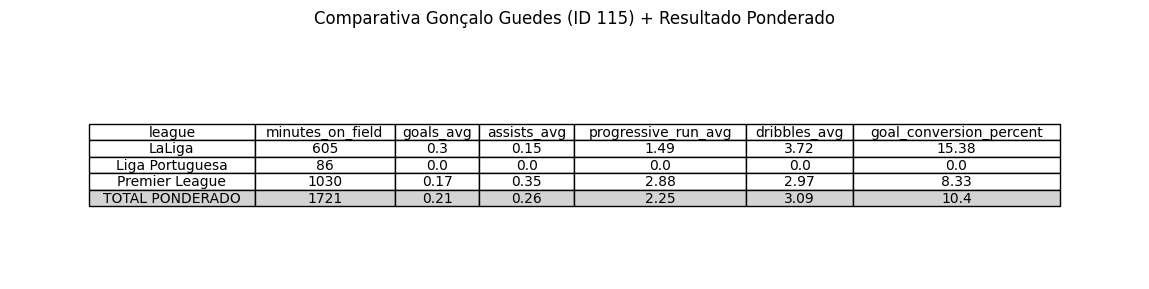

In [15]:
import matplotlib.pyplot as plt

final_table = final_table.fillna(0)

# Redondear para que no quede feo
final_table_rounded = final_table.round(2)

# Crear figura
fig, ax = plt.subplots(figsize=(12, 3))
ax.axis('off')  # quitar ejes

# Crear tabla
table = ax.table(
    cellText=final_table_rounded.values,
    colLabels=final_table_rounded.columns,
    loc='center',
    cellLoc='center'
)

# Ajustes visuales
table.auto_set_font_size(False)
table.set_fontsize(10)
table.auto_set_column_width(col=list(range(len(final_table_rounded.columns))))

# Resaltar fila final (ponderado)
n_rows = len(final_table_rounded)

for col in range(len(final_table_rounded.columns)):
    table[(n_rows, col)].set_facecolor('#d3d3d3')  # gris claro

# Título
plt.title("Comparativa Gonçalo Guedes (ID 115) + Resultado Ponderado", pad=20)

plt.tight_layout()
plt.show()

C:\Users\Germán Llorente\AppData\Local\Temp\ipykernel_31852\1393430290.py:18: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(subset["metric"], rotation=45)


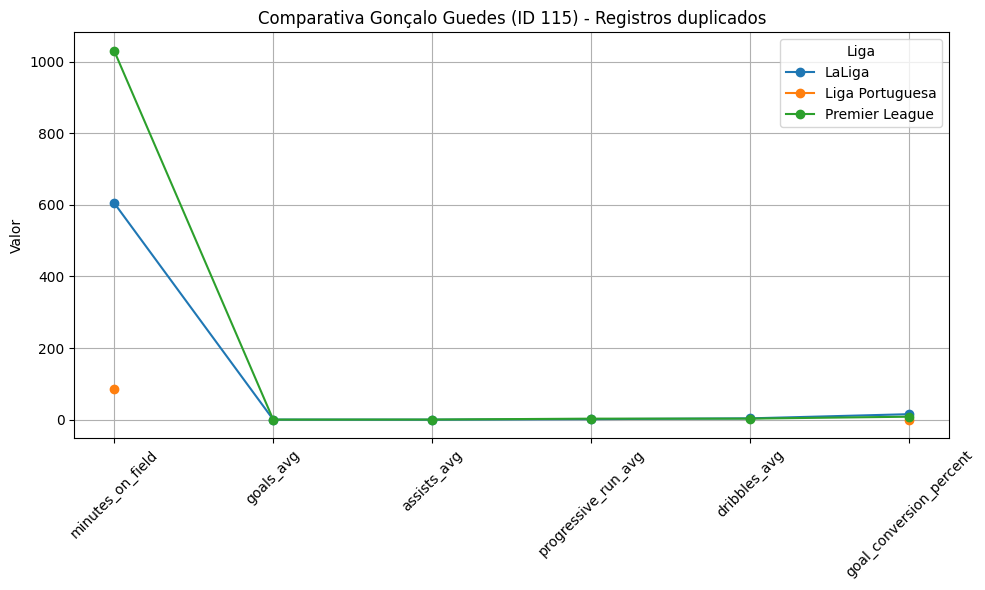

In [16]:
import matplotlib.pyplot as plt

# Pasar a formato largo
guedes_melt = guedes_stats.melt(
    id_vars=["league"],
    var_name="metric",
    value_name="value"
)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

for league in guedes_melt["league"].unique():
    subset = guedes_melt[guedes_melt["league"] == league]
    ax.plot(subset["metric"], subset["value"], marker='o', label=league)

ax.set_title("Comparativa Gonçalo Guedes (ID 115) - Registros duplicados")
ax.set_xticklabels(subset["metric"], rotation=45)
ax.set_ylabel("Valor")
ax.legend(title="Liga")
ax.grid(True)

plt.tight_layout()
plt.show()

In [17]:
df.loc[df["id"] == 327006, "name"] = "Ali Al Musrati"
df.loc[df["id"] == 324260, "name"] = "J. Siebatcheu"

In [18]:
def combinar_jugador(grupo):

    resultado = {}

    minutos = grupo["minutes_on_field"]

    # -------------------------
    # 1. MÉTRICAS NUMÉRICAS
    # -------------------------
    columnas_num = grupo.select_dtypes(include=np.number).columns

    for col in columnas_num:
        if col != "minutes_on_field":

            valores = grupo[col]

            # 🔹 CASO _avg
            if col.endswith("_avg"):

                if valores.notna().sum() == 0:
                    resultado[col] = np.nan
                else:
                    valores = valores.fillna(0)

                    if minutos.notna().sum() > 0 and minutos.sum() > 0:
                        resultado[col] = np.average(valores, weights=minutos.fillna(0))
                    else:
                        resultado[col] = np.nan

            # 🔹 RESTO DE MÉTRICAS
            else:
                mask = valores.notna() & minutos.notna()

                if mask.sum() > 0 and minutos[mask].sum() > 0:
                    resultado[col] = np.average(valores[mask], weights=minutos[mask])
                else:
                    resultado[col] = np.nan

    # -------------------------
    # 2. MINUTOS
    # -------------------------
    resultado["minutes_on_field"] = minutos.sum(skipna=True)

    # -------------------------
    # 3. INFO BÁSICA
    # -------------------------
    resultado["id"] = grupo["id"].iloc[0]

    resultado["name"] = (
        grupo["name"].mode().iloc[0]
        if grupo["name"].notna().sum() > 0 else np.nan
    )

    resultado["birth_date"] = (
        grupo["birth_date"].iloc[0]
        if grupo["birth_date"].notna().sum() > 0 else np.nan
    )

    resultado["age"] = (
        grupo["age"].iloc[0]
        if grupo["age"].notna().sum() > 0 else np.nan
    )

    resultado["primary_position"] = (
        grupo["primary_position"].mode().iloc[0]
        if grupo["primary_position"].notna().sum() > 0 else np.nan
    )

    # -------------------------
    # 4. EQUIPO DOMINANTE
    # -------------------------
    if minutos.notna().sum() > 0 and minutos.sum() > 0:
        idx_max = minutos.fillna(0).idxmax()
        resultado["current_team_name"] = grupo.loc[idx_max, "current_team_name"]
    else:
        resultado["current_team_name"] = np.nan

    # -------------------------
    # 5. LIGAS
    # -------------------------
    resultado["league"] = ", ".join(sorted(grupo["league"].dropna().unique()))
    resultado["n_leagues"] = grupo["league"].nunique()

    # -------------------------
    # 6. RESTO DE COLUMNAS (CLAVE)
    # -------------------------
    for col in grupo.columns:
        if col not in resultado:

            valores = grupo[col].dropna()

            if len(valores) > 0:
                # puedes cambiar esto por mode() si prefieres
                resultado[col] = valores.iloc[0]
            else:
                resultado[col] = np.nan

    return pd.Series(resultado)

# APLICAR
df_final = (
    df
    .groupby(["id"])
    .apply(combinar_jugador)
    .reset_index(drop=True)
)

In [19]:
print("Jugadores únicos finales:", df_final.shape[0])
print("Jugadores con múltiples ligas:", (df_final["n_leagues"] > 1).sum())

Jugadores únicos finales: 3924
Jugadores con múltiples ligas: 301


In [20]:
df.loc[df["name"] == "Juan Bernat", ["id", "name", "minutes_on_field", "league", "goal_conversion_percent", "goals_avg","assists_avg"]]

,id,name,minutes_on_field,league,goal_conversion_percent,goals_avg,assists_avg
1236,204842,Juan Bernat,981,LaLiga,0.0,0.0,0.09
1412,204842,Juan Bernat,10,Liga Portuguesa,0.0,NaN,NaN


In [21]:
df_final.loc[df_final["name"] == "Juan Bernat", ["id", "name", "minutes_on_field", "league", "goal_conversion_percent", "goals_avg", "assists_avg"]]

,id,name,minutes_on_field,league,goal_conversion_percent,goals_avg,assists_avg
2213,204842,Juan Bernat,991,"LaLiga, Liga Portuguesa",0.0,0.0,0.089092


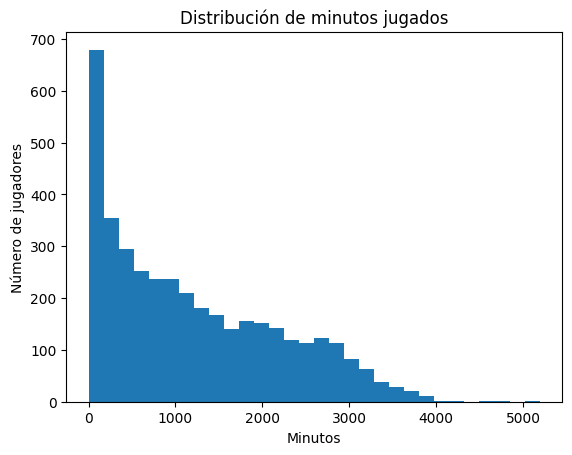

In [22]:
import matplotlib.pyplot as plt
#comprobar minutos jugados

plt.hist(df_final["minutes_on_field"], bins=30)
plt.title("Distribución de minutos jugados")
plt.xlabel("Minutos")
plt.ylabel("Número de jugadores")
plt.show()

In [23]:
df_final["minutes_on_field"].describe()

count    3924.000000
mean     1201.892202
std       999.450496
min         1.000000
25%       316.500000
50%       968.000000
75%      1942.000000
max      5191.000000
Name: minutes_on_field, dtype: float64

In [24]:
percentiles = df_final["minutes_on_field"].quantile([0.1, 0.2, 0.25, 0.3, 0.35, 0.4])
print(percentiles)

0.10     72.0
0.20    214.6
0.25    316.5
0.30    434.9
0.35    553.0
0.40    685.0
Name: minutes_on_field, dtype: float64


In [25]:
# marca de minutos jugados insuficientes  (553 minutos)

threshold = df_final["minutes_on_field"].quantile(0.35)

df_final["low_minutes_flag"] = df_final["minutes_on_field"] < threshold

porcentaje = df_final["low_minutes_flag"].mean() * 100

print(f"Threshold: {threshold:.0f} minutos")
print(f"Jugadores marcados como outliers: {porcentaje:.2f}%")

Threshold: 553 minutos
Jugadores marcados como outliers: 34.94%


Limpieza de columnas

In [26]:
import pandas as pd
import numpy as np

# copia de seguridad
df_final = df_final.copy()

# -------------------------
# 1. Normalizar strings vacíos
# -------------------------
cols_str = [
    "foot",
    "current_team_name",
    "current_team_color",
    "current_team_logo"
]

for col in cols_str:
    if col in df_final.columns:
        df_final[col] = df_final[col].replace(r"^\s*$", np.nan, regex=True)

# -------------------------
# 2. FOOT
# -------------------------
if "foot" in df_final.columns:
    df_final["foot"] = df_final["foot"].replace([0, "0"], np.nan)
    df_final["foot"] = df_final["foot"].fillna("unknown")
    df_final["foot"] = df_final["foot"].astype(str).str.strip().str.lower()

    # opcional: limitar valores válidos
    valid_foot = ["left", "right", "both", "unknown"]
    df_final.loc[~df_final["foot"].isin(valid_foot), "foot"] = "unknown"

# -------------------------
# 3. HEIGHT y WEIGHT
# -------------------------
for col in ["height", "weight"]:
    if col in df_final.columns:
        df_final[col] = pd.to_numeric(df_final[col], errors="coerce")
        df_final.loc[df_final[col] == 0, col] = np.nan

# -------------------------
# 4. CURRENT_TEAM_NAME
# -------------------------
if "current_team_name" in df_final.columns:
    df_final["current_team_name"] = df_final["current_team_name"].replace([0, "0"], np.nan)

    # opción A: mantener nulos
    # no hacer nada más

    # opción B: rellenar si no quieres nulos en BD
    # df_final["current_team_name"] = df_final["current_team_name"].fillna("Unknown team")

# -------------------------
# 5. CURRENT_TEAM_COLOR
# -------------------------
if "current_team_color" in df_final.columns:
    df_final["current_team_color"] = df_final["current_team_color"].replace([0, "0"], np.nan)

    # si quieres validar formato hexadecimal simple
    mask_invalid_color = (
        df_final["current_team_color"].notna() &
        ~df_final["current_team_color"].astype(str).str.fullmatch(r"[0-9A-Fa-f]{6}")
    )
    df_final.loc[mask_invalid_color, "current_team_color"] = np.nan

# -------------------------
# 6. CURRENT_TEAM_LOGO
# -------------------------
if "current_team_logo" in df_final.columns:
    df_final["current_team_logo"] = df_final["current_team_logo"].replace([0, "0"], np.nan)

# -------------------------
# 7. REVISIÓN RÁPIDA
# -------------------------
cols_check = [
    "foot", "height", "weight",
    "current_team_name", "current_team_color", "current_team_logo"
]

print(df_final[cols_check].isna().sum())
print(df_final[cols_check].head())

foot                    0
height                187
weight                247
current_team_name      75
current_team_color     74
current_team_logo      74
dtype: int64
      foot  height  weight current_team_name current_team_color  \
0  unknown     NaN     NaN          Basconia             d13125   
1    right   187.0     NaN             Brest             da352e   
2  unknown     NaN     NaN      Milan Futuro             000000   
3     left     NaN     NaN               NaN                NaN   
4  unknown     NaN     NaN        RB Leipzig             ff0000   

                                   current_team_logo  
0  https://cdn5.wyscout.com/photos/team/public/g1...  
1  https://cdn5.wyscout.com/photos/team/public/39...  
2  https://cdn5.wyscout.com/photos/team/public/g-...  
3                                                NaN  
4  https://cdn5.wyscout.com/photos/team/public/37...  


In [27]:
df_final["current_team_name"] = df_final["current_team_name"].fillna("Unknown team")

In [28]:
df_final["current_team_color"] = df_final["current_team_color"].replace("000000", np.nan)

In [29]:
df_final

,id,age,market_value,total_matches,primary_position_percent,secondary_position_percent,third_position_percent,height,weight,goals,...,current_team_logo,current_team_color,last_club_name,contract_expires,on_loan,positions,secondary_position,third_position,foot,low_minutes_flag
0,-768817,18.0,0.0,1.000000,100.000000,0.000000,0.000000,NaN,NaN,0.000000,...,https://cdn5.wyscout.com/photos/team/public/g1...,d13125,Basconia,2029-06-30,False,AMF,NaN,NaN,unknown,True
1,-736582,20.0,0.0,4.000000,40.000000,38.000000,12.000000,187.0,NaN,0.000000,...,https://cdn5.wyscout.com/photos/team/public/39...,da352e,Brest,NaN,False,CF|RWF|LW,RWF,LW,right,True
2,-730558,18.0,0.0,2.000000,100.000000,0.000000,0.000000,NaN,NaN,0.000000,...,https://cdn5.wyscout.com/photos/team/public/g-...,NaN,Milan Futuro,NaN,False,CF,NaN,NaN,unknown,True
3,-709387,19.0,0.0,1.000000,100.000000,0.000000,0.000000,NaN,NaN,0.000000,...,NaN,NaN,Las Palmas,NaN,False,RAMF,NaN,NaN,left,True
4,-695150,19.0,0.0,10.526848,44.161089,30.419455,13.892607,NaN,NaN,2.526848,...,https://cdn5.wyscout.com/photos/team/public/37...,ff0000,RB Leipzig,NaN,False,RWF|LWF|LAMF,LWF,LAMF,unknown,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3919,522284,24.0,100000.0,5.000000,100.000000,0.000000,0.000000,185.0,81.0,0.000000,...,https://cdn5.wyscout.com/photos/team/public/20...,NaN,Auxerre,2026-06-30,False,GK,NaN,NaN,right,True
3920,522867,25.0,22000000.0,22.000000,92.000000,0.000000,0.000000,186.0,76.0,3.000000,...,https://cdn5.wyscout.com/photos/team/public/60...,d13125,Athletic Club,2029-06-30,False,LCB,NaN,NaN,right,False
3921,523522,25.0,750000.0,31.000000,82.000000,0.000000,0.000000,187.0,73.0,0.000000,...,https://cdn5.wyscout.com/photos/team/public/15...,f4070e,Santa Clara,2027-06-30,False,LCMF,NaN,NaN,right,False
3922,523653,23.0,22000000.0,26.000000,64.000000,17.000000,0.000000,188.0,73.0,0.000000,...,https://cdn5.wyscout.com/photos/team/public/30...,e73a41,Southampton,2028-06-30,False,RCB3|LCB3,LCB3,NaN,right,False


Feature engineering

In [30]:
# columnas que vas a usar en métricas nuevas
cols_needed = [
    "goals_avg", "xg_shot_avg", "assists_avg",
    "key_passes_avg", "passes_avg", "accurate_passes_percent",
    "crosses_avg", "accurate_crosses_percent",
    "progressive_pass_avg", "successful_progressive_pass_percent",
    "dribbles_avg", "successful_dribbles_percent",
    "progressive_run_avg",
    "duels_avg", "duels_won",
    "aerial_duels_avg", "aerial_duels_won",
    "interceptions_avg", "tackle_avg",
    "successful_defensive_actions_avg",
    "yellow_cards_avg", "red_cards_avg",
    "fouls_avg", "foul_suffered_avg"
]

# rellenar SOLO estas con 0
df_final[cols_needed] = df_final[cols_needed].fillna(0)

In [31]:
df_final["accurate_pass_avg"] = (
    df_final["passes_avg"] * df_final["accurate_passes_percent"] / 100
)

In [32]:
df_final["accurate_crosses_avg"] = (
    df_final["crosses_avg"] * df_final["accurate_crosses_percent"] / 100
)

In [33]:
df_final["accurate_progressive_pass_avg"] = (
    df_final["progressive_pass_avg"] * df_final["successful_progressive_pass_percent"] / 100
)

In [34]:
df_final["dribble_efficiency"] = (
    df_final["dribbles_avg"] * df_final["successful_dribbles_percent"] / 100
)

In [35]:
df_final["real_progression"] = (
    df_final["progressive_run_avg"] + df_final["progressive_pass_avg"]
)

In [36]:
df_final["duels_won_avg"] = (
    df_final["duels_avg"] * df_final["duels_won"] / 100
)

In [37]:
df_final["aerial_duels_won_avg"] = (
    df_final["aerial_duels_avg"] * df_final["aerial_duels_won"] / 100
)

Conversión de las variables de tiro libre directo, córner y penalti

In [38]:
cols_set_pieces = [
    "direct_free_kicks_taken_avg",
    "corners_taken_avg",
    "penalties_taken"
]

df_final[cols_set_pieces].describe()

,direct_free_kicks_taken_avg,corners_taken_avg,penalties_taken
count,2586.000000,2795.000000,3924.000000
mean,0.032471,0.376672,0.165544
std,0.084151,0.772792,0.736594
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000
75%,0.000000,0.280000,0.000000
max,0.800000,4.720000,12.000000


In [39]:
for col in cols_set_pieces:
    print(f"\n--- {col} ---")
    print(df_final[col].quantile([0.5, 0.65, 0.7, 0.75, 0.9, 0.95, 0.99]))


--- direct_free_kicks_taken_avg ---
0.50    0.000
0.65    0.000
0.70    0.000
0.75    0.000
0.90    0.120
0.95    0.200
0.99    0.403
Name: direct_free_kicks_taken_avg, dtype: float64

--- corners_taken_avg ---
0.50    0.0000
0.65    0.0500
0.70    0.1300
0.75    0.2800
0.90    1.6220
0.95    2.2600
0.99    3.3224
Name: corners_taken_avg, dtype: float64

--- penalties_taken ---
0.50    0.0
0.65    0.0
0.70    0.0
0.75    0.0
0.90    0.0
0.95    1.0
0.99    4.0
Name: penalties_taken, dtype: float64


In [40]:
df_final["positions"]

0                AMF
1          CF|RWF|LW
2                 CF
3               RAMF
4       RWF|LWF|LAMF
            ...     
3919              GK
3920             LCB
3921            LCMF
3922       RCB3|LCB3
3923      RCMF3|RCMF
Name: positions, Length: 3924, dtype: object

In [41]:
df_final["positions_clean"] = df_final["positions"].fillna("").apply(
    lambda x: [p.strip() for p in x.split("|") if p.strip() != ""]
)

In [42]:
df_final["positions_clean"]

0                  [AMF]
1          [CF, RWF, LW]
2                   [CF]
3                 [RAMF]
4       [RWF, LWF, LAMF]
              ...       
3919                [GK]
3920               [LCB]
3921              [LCMF]
3922        [RCB3, LCB3]
3923       [RCMF3, RCMF]
Name: positions_clean, Length: 3924, dtype: object

In [43]:
all_positions = set()

for pos_list in df_final["positions_clean"]:
    for p in pos_list:
        all_positions.add(p)

all_positions = sorted(all_positions)

print(all_positions)
print("Número de posiciones distintas:", len(all_positions))

['AMF', 'CB', 'CF', 'DMF', 'GK', 'LAMF', 'LB', 'LB5', 'LCB', 'LCB3', 'LCMF', 'LCMF3', 'LDMF', 'LW', 'LWB', 'LWF', 'RAMF', 'RB', 'RB5', 'RCB', 'RCB3', 'RCMF', 'RCMF3', 'RDMF', 'RW', 'RWB', 'RWF']
Número de posiciones distintas: 27


In [44]:
import re

def clean_pos(p):
    return re.sub(r'\d+', '', p)

def map_main_position(pos):
    
    if pd.isna(pos):
        return "OTHER"
    
    p = clean_pos(pos)
    
    # PORTERO
    if p == "GK":
        return "GK"
    
    # CENTRALES
    if p in ["CB", "LCB", "RCB"]:
        return "CB"
    
    # LATERALES
    if p in ["LB"]:
        return "LB"
    if p in ["RB"]:
        return "RB"
    
    # CARRILEROS
    if p in ["LWB"]:
        return "LWB"
    if p in ["RWB"]:
        return "RWB"
    
    # MEDIOCENTRO DEFENSIVO
    if p in ["DMF", "LDMF", "RDMF"]:
        return "DMF"
    
    # MEDIOCENTRO
    if p in ["CMF", "LCMF", "RCMF"]:
        return "MF"
    
    # MEDIAPUNTA
    if p in ["AMF"]:
        return "AM"
    
    # EXTREMOS
    if p in ["LW", "LAMF", "LWF"]:
        return "LW"
    if p in ["RW", "RAMF", "RWF"]:
        return "RW"
    
    # DELANTERO
    if p in ["CF", "ST"]:
        return "FW"
    
    return "OTHER"

In [45]:
df_final["main_position"] = df_final["primary_position"].apply(map_main_position)

In [46]:
df_final["main_position"].value_counts()

CB     718
FW     601
MF     479
RW     316
LW     300
DMF    289
GK     282
RB     262
LB     261
AM     233
LWB     92
RWB     91
Name: main_position, dtype: int64

Valor de mercado

In [47]:
total = len(df_final)
sin_valor = (df_final["market_value"] == 0).sum()

porcentaje = sin_valor / total * 100

print(f"{sin_valor} jugadores sin valor de mercado ({porcentaje:.2f}%)")

942 jugadores sin valor de mercado (24.01%)


In [48]:
df_sin_valor = df_final[df_final["market_value"] == 0]

distribucion = df_sin_valor["age"].value_counts().sort_index()

print(distribucion)

13.0      1
15.0      1
16.0      5
17.0     31
18.0     87
19.0    138
20.0    180
21.0    131
22.0    128
23.0     70
24.0     42
25.0     37
26.0     17
27.0     18
28.0     20
29.0     14
30.0      5
31.0      5
32.0      5
33.0      3
34.0      1
37.0      1
Name: age, dtype: int64


In [49]:
bins = [0, 18, 21, 24, 27, 30, 35, 40]
labels = ["<18", "18-21", "22-24", "25-27", "28-30", "31-35", "36+"]

df_sin_valor["age_group"] = pd.cut(df_sin_valor["age"], bins=bins, labels=labels)

print(df_sin_valor["age_group"].value_counts().sort_index())

<18      125
18-21    449
22-24    240
25-27     72
28-30     39
31-35     14
36+        1
Name: age_group, dtype: int64


C:\Users\Germán Llorente\AppData\Local\Temp\ipykernel_31852\505705387.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sin_valor["age_group"] = pd.cut(df_sin_valor["age"], bins=bins, labels=labels)


In [50]:
def format_market_value(x):
    if x == 0 or pd.isna(x):
        return "No disponible / 0 €"
    elif x >= 1e6:
        return f"€{x/1e6:.1f}M"
    elif x >= 1e3:
        return f"€{x/1e3:.0f}K"
    else:
        return f"€{x}"

df_final["market_value_str"] = df_final["market_value"].apply(format_market_value)

Crear métricas de balón parado

In [51]:
#tiros libres directos
threshold_fk = df_final["direct_free_kicks_taken_avg"].quantile(0.9)

df_final["direct_free_kick_taker"] = df_final["direct_free_kicks_taken_avg"] >= threshold_fk

In [52]:
#sacador de corners
threshold_corner = df_final["corners_taken_avg"].quantile(0.65)

df_final["corner_taker"] = df_final["corners_taken_avg"] >= threshold_corner

In [53]:
#tirador de penaltis
df_final["penalty_taker"] = df_final["penalties_taken"] >= 1

In [54]:
df_final["shot_efficiency_avg"] = df_final["goals_avg"] - df_final["xg_shot_avg"]

In [55]:
for column in df_final.columns:

    print(column)

id
age
market_value
total_matches
primary_position_percent
secondary_position_percent
third_position_percent
height
weight
goals
goals_avg
non_penalty_goal
non_penalty_goal_avg
head_goals
head_goals_avg
shots
shots_avg
shots_on_target_percent
goal_conversion_percent
xg_shot
xg_shot_avg
touch_in_box_avg
assists
assists_avg
xg_assist
xg_assist_avg
key_passes_avg
shot_assists_avg
pre_assist_avg
pre_pre_assist_avg
passes_avg
accurate_passes_percent
forward_passes_avg
successful_forward_passes_percent
back_passes_avg
successful_back_passes_percent
vertical_passes_avg
successful_vertical_passes_percent
short_medium_pass_avg
accurate_short_medium_pass_percent
long_passes_avg
successful_long_passes_percent
average_pass_length
average_long_pass_length
deep_completed_pass_avg
deep_completed_cross_avg
pass_to_penalty_area_avg
accurate_pass_to_penalty_area_percent
passes_to_final_third_avg
accurate_passes_to_final_third_percent
through_passes_avg
successful_through_passes_percent
smart_passes_avg


In [56]:
cols = ["id", "name", "full_name", "age", "birth_date", "passport_country_names", "league", "current_team_name", "current_team_logo", "current_team_color", "contract_expires", "market_value", "market_value_str", "minutes_on_field", "low_minutes_flag", "total_matches", "on_loan", "main_position", "positions_clean", "foot", "height", "weight", "goals_avg", "non_penalty_goal_avg", "head_goals_avg", "shots_on_target_percent", "shot_efficiency_avg", "xg_shot_avg", "assists_avg", "xg_assist_avg", "key_passes_avg", "passes_avg", "accurate_passes_percent", "accurate_pass_avg", "crosses_avg", "accurate_crosses_percent", "accurate_crosses_avg", "progressive_pass_avg", "successful_progressive_pass_percent", "accurate_progressive_pass_avg", "dribbles_avg", "successful_dribbles_percent", "dribble_efficiency", "progressive_run_avg", "real_progression", "duels_avg", "duels_won", "duels_won_avg", "offensive_duels_won", "defensive_duels_won", "aerial_duels_avg", "aerial_duels_won", "aerial_duels_won_avg", "successful_defensive_actions_avg", "tackle_avg", "interceptions_avg", "shot_block_avg", "conceded_goals_avg", "shots_against_avg", "save_percent", "xg_save_avg", "prevented_goals_avg", "goalkeeper_exits_avg", "gk_aerial_duels_avg", "direct_free_kick_taker", "direct_free_kicks_on_target_percent", "corner_taker", "penalty_taker", "penalties_conversion_percent", "fouls_avg", "foul_suffered_avg", "yellow_cards_avg", "red_cards_avg"]

In [57]:
player_stats = df_final[cols]

In [58]:
for column in player_stats.columns:
    print(column)

id
name
full_name
age
birth_date
passport_country_names
league
current_team_name
current_team_logo
current_team_color
contract_expires
market_value
market_value_str
minutes_on_field
low_minutes_flag
total_matches
on_loan
main_position
positions_clean
foot
height
weight
goals_avg
non_penalty_goal_avg
head_goals_avg
shots_on_target_percent
shot_efficiency_avg
xg_shot_avg
assists_avg
xg_assist_avg
key_passes_avg
passes_avg
accurate_passes_percent
accurate_pass_avg
crosses_avg
accurate_crosses_percent
accurate_crosses_avg
progressive_pass_avg
successful_progressive_pass_percent
accurate_progressive_pass_avg
dribbles_avg
successful_dribbles_percent
dribble_efficiency
progressive_run_avg
real_progression
duels_avg
duels_won
duels_won_avg
offensive_duels_won
defensive_duels_won
aerial_duels_avg
aerial_duels_won
aerial_duels_won_avg
successful_defensive_actions_avg
tackle_avg
interceptions_avg
shot_block_avg
conceded_goals_avg
shots_against_avg
save_percent
xg_save_avg
prevented_goals_avg
goal

In [59]:
cols_quit = ["passes_avg", "crosses_avg", "progressive_pass_avg", "dribbles_avg", "duels_avg", "aerial_duels_avg"]

In [60]:
player_stats = player_stats.drop(columns=cols_quit)

Cargar rol clustering

In [61]:

cb = pd.read_csv("clustering/data/cb_clusters.csv")
fb = pd.read_csv("clustering/data/fb_clusters.csv")
mf = pd.read_csv("clustering/data/mf_clusters.csv")
am = pd.read_csv("clustering/data/am_clusters.csv")
w = pd.read_csv("clustering/data/w_clusters.csv")
fw = pd.read_csv("clustering/data/fw_clusters.csv")
gk = pd.read_csv("clustering/data/gk_clusters.csv")
wb = pd.read_csv("clustering/data/wb_clusters.csv")

In [62]:
all_clusters = pd.concat([cb, fb, mf, am, w, fw, gk, wb], ignore_index=True)

In [63]:
player_stats = player_stats.merge(
    all_clusters[["id", "player_role"]],
    on="id",
    how="left"
)

In [64]:
player_stats["player_role"] = player_stats["player_role"].fillna("No role assigned")

In [65]:
player_stats["player_role"].isna().sum()

0

In [66]:
player_stats.to_csv("data/player_data_v1.csv", index=False)

In [67]:
player_stats

,id,name,full_name,age,birth_date,passport_country_names,league,current_team_name,current_team_logo,current_team_color,...,direct_free_kick_taker,direct_free_kicks_on_target_percent,corner_taker,penalty_taker,penalties_conversion_percent,fouls_avg,foul_suffered_avg,yellow_cards_avg,red_cards_avg,player_role
0,-768817,S. Sued,Selton Sued,18.0,2007-02-20,Spain,LaLiga,Basconia,https://cdn5.wyscout.com/photos/team/public/g1...,d13125,...,False,NaN,False,False,0.0,0.000000,0.000000,0.000000,0.00,No role assigned
1,-736582,S. Diop,Saliou Diop,20.0,2005-05-12,Senegal,Ligue 1,Brest,https://cdn5.wyscout.com/photos/team/public/39...,da352e,...,False,NaN,False,False,0.0,0.000000,0.000000,0.000000,0.00,No role assigned
2,-730558,C. Mul-Balentien,Cheveyo Mul-Balentien,18.0,2006-12-18,Netherlands,SerieA,Milan Futuro,https://cdn5.wyscout.com/photos/team/public/g-...,NaN,...,False,NaN,False,False,0.0,0.000000,0.000000,0.000000,0.00,No role assigned
3,-709387,A. Rodriguez Cosano,Arturo Rodriguez Cosano,19.0,2006-08-05,Spain,LaLiga,Unknown team,NaN,NaN,...,False,NaN,False,False,0.0,0.000000,0.000000,0.000000,0.00,No role assigned
4,-695150,Y. Diomande,Yan Diomande,19.0,2006-11-14,Spain,"Bundesliga, LaLiga",RB Leipzig,https://cdn5.wyscout.com/photos/team/public/37...,ff0000,...,False,0.0,False,False,0.0,0.977012,1.400599,0.213222,0.00,Dribbler winger
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3919,522284,T. De Percin,Théo De Percin,24.0,2001-02-02,France|Martinique,Ligue 1,Auxerre,https://cdn5.wyscout.com/photos/team/public/20...,NaN,...,False,NaN,False,False,0.0,0.000000,0.200000,0.000000,0.00,No role assigned
3920,522867,Aitor Paredes,Aitor Paredes Casamichana,25.0,2000-04-29,Spain,LaLiga,Athletic Club,https://cdn5.wyscout.com/photos/team/public/60...,d13125,...,False,0.0,False,False,0.0,0.830000,0.290000,0.050000,0.00,Low-impact CB
3921,523522,Adriano Firmino,Adriano Firmino dos Santos da Silva,25.0,1999-11-04,Brazil,Liga Portuguesa,Santa Clara,https://cdn5.wyscout.com/photos/team/public/15...,f4070e,...,False,0.0,False,False,0.0,1.300000,0.650000,0.260000,0.03,Box-to-box midfielder
3922,523653,T. Harwood-Bellis,Taylor Harwood-Bellis,23.0,2002-01-30,England,Premier League,Southampton,https://cdn5.wyscout.com/photos/team/public/30...,e73a41,...,False,0.0,False,False,0.0,0.870000,0.470000,0.220000,0.00,Ball-playing CB


In [68]:
filter_total = ["successful_vertical_passes_percent.1",
"successful_back_passes_percent.1",
"successful_long_passes_percent.1",
"successful_cross_from_left_percent.1",
"successful_cross_from_right_percent.1",
"successful_through_passes_percent.1",
"successful_smart_passes_percent",
"successful_progressive_pass_percent.1",
"successful_attacking_actions_avg.1",
"back_pass_to_gk_avg.1",
"average_pass_length.1",
"average_long_pass_length.1",
"prevented_goals.1",
"prevented_goals_avg.1"]

In [69]:
df_final = df_final.drop(columns=filter_total)

In [70]:
df_final.to_csv("data/player_data_COMPLETE.csv", index=False)

Normalización score = 0.7 * percentile + 0.3 * minmax

In [71]:
for col in player_stats.columns:
    print(col)

id
name
full_name
age
birth_date
passport_country_names
league
current_team_name
current_team_logo
current_team_color
contract_expires
market_value
market_value_str
minutes_on_field
low_minutes_flag
total_matches
on_loan
main_position
positions_clean
foot
height
weight
goals_avg
non_penalty_goal_avg
head_goals_avg
shots_on_target_percent
shot_efficiency_avg
xg_shot_avg
assists_avg
xg_assist_avg
key_passes_avg
accurate_passes_percent
accurate_pass_avg
accurate_crosses_percent
accurate_crosses_avg
successful_progressive_pass_percent
accurate_progressive_pass_avg
successful_dribbles_percent
dribble_efficiency
progressive_run_avg
real_progression
duels_won
duels_won_avg
offensive_duels_won
defensive_duels_won
aerial_duels_won
aerial_duels_won_avg
successful_defensive_actions_avg
tackle_avg
interceptions_avg
shot_block_avg
conceded_goals_avg
shots_against_avg
save_percent
xg_save_avg
prevented_goals_avg
goalkeeper_exits_avg
gk_aerial_duels_avg
direct_free_kick_taker
direct_free_kicks_on_tar

In [72]:
variables_extra = [
    "id", "name", "full_name", "age", "birth_date",
    "passport_country_names", "league", "current_team_name",
    "current_team_logo", "current_team_color",
    "contract_expires", "market_value", "market_value_str", "minutes_on_field",
    "low_minutes_flag", "total_matches", "on_loan",
    "main_position", "positions_clean", "foot",
    "height", "weight", "direct_free_kick_taker", "corner_taker", "penalty_taker", "player_role"
]

metricas = [
    col for col in player_stats.columns 
    if col not in variables_extra
]

In [73]:
print(metricas)

['goals_avg', 'non_penalty_goal_avg', 'head_goals_avg', 'shots_on_target_percent', 'shot_efficiency_avg', 'xg_shot_avg', 'assists_avg', 'xg_assist_avg', 'key_passes_avg', 'accurate_passes_percent', 'accurate_pass_avg', 'accurate_crosses_percent', 'accurate_crosses_avg', 'successful_progressive_pass_percent', 'accurate_progressive_pass_avg', 'successful_dribbles_percent', 'dribble_efficiency', 'progressive_run_avg', 'real_progression', 'duels_won', 'duels_won_avg', 'offensive_duels_won', 'defensive_duels_won', 'aerial_duels_won', 'aerial_duels_won_avg', 'successful_defensive_actions_avg', 'tackle_avg', 'interceptions_avg', 'shot_block_avg', 'conceded_goals_avg', 'shots_against_avg', 'save_percent', 'xg_save_avg', 'prevented_goals_avg', 'goalkeeper_exits_avg', 'gk_aerial_duels_avg', 'direct_free_kicks_on_target_percent', 'penalties_conversion_percent', 'fouls_avg', 'foul_suffered_avg', 'yellow_cards_avg', 'red_cards_avg']


In [74]:
def agrupar_posicion(p):

    # PORTERO
    if p == "GK":
        return "GK"
    
    # CENTRALES
    if p in ["CB", "LCB", "RCB"]:
        return "CB"
    
    # LATERALES
    if p == "LB":
        return "LB"
    if p == "RB":
        return "RB"
    
    # CARRILEROS
    if p == "LWB":
        return "LWB"
    if p == "RWB":
        return "RWB"
    
    # MEDIOCENTROS (LOS JUNTAS)
    if p in ["DMF", "LDMF", "RDMF", "CMF", "LCMF", "RCMF"]:
        return "MF"
    
    # MEDIAPUNTA
    if p in ["AMF", "AM"]:
        return "AM"
    
    # EXTREMOS
    if p in ["LW", "LAMF", "LWF"]:
        return "LW"
    if p in ["RW", "RAMF", "RWF"]:
        return "RW"
    
    # DELANTERO
    if p in ["CF", "ST", "FW"]:
        return "FW"
    
    else:
    
        return "OTHER"

In [75]:
def normalizacion_mixta_por_posicion(
    df,
    metricas,
    variables_extra,
):

    df = df.copy()

    # agrupar posiciones
    df["pos_group"] = df["main_position"].apply(agrupar_posicion)

    # separar jugadores válidos
    df_valid = df[df["low_minutes_flag"] == False].copy()

    resultados = []

    # iterar por grupo de posición
    for pos in df_valid["pos_group"].unique():

        df_pos = df_valid[df_valid["pos_group"] == pos].copy()

        columnas_existentes = [col for col in metricas if col in df_pos.columns]

        df_out = df_pos[variables_extra + ["pos_group"] + columnas_existentes].copy()

        for col in columnas_existentes:

            valores = pd.to_numeric(df_out[col], errors="coerce")

            # --- MINMAX ---
            min_val = valores.min()
            max_val = valores.max()

            if pd.notnull(min_val) and pd.notnull(max_val) and max_val != min_val:
                minmax = (valores - min_val) / (max_val - min_val) * 100
            else:
                minmax = pd.Series(0, index=valores.index)

            # --- PERCENTIL ---
            percentile = valores.rank(pct=True) * 100

            # --- MIX ---
            df_out[col] = 0.7 * percentile + 0.3 * minmax

            # --- truncar ---
            df_out[col] = np.floor(df_out[col] * 100) / 100

        resultados.append(df_out)

    # unir todo
    df_final = pd.concat(resultados, ignore_index=True)

    return df_final

In [76]:

df_normalizado = normalizacion_mixta_por_posicion(
    player_stats,
    metricas,
    variables_extra
)

df_normalizado.to_csv("data/player_data_normalized.csv", index=False)

In [77]:
player_stats["main_position"].unique()

array(['AM', 'FW', 'RW', 'LW', 'CB', 'RB', 'MF', 'RWB', 'DMF', 'LB',
       'LWB', 'GK'], dtype=object)

Gráfico Radar

In [78]:
radar_config = {

    "goalkeeper": (
        ["save_percent", "xg_save_avg", "prevented_goals_avg",
         "goalkeeper_exits_avg", "gk_aerial_duels_avg", "shots_against_avg"],
        ["Paradas %", "xG parada", "Goles evitados",
         "Salidas", "Aéreo GK", "Tiros recibidos"]
    ),

    "center back": (
        ["defensive_duels_won", "aerial_duels_won_avg", "interceptions_avg",
         "tackle_avg", "shot_block_avg", "accurate_passes_percent"],
        ["Duelos def.", "Aéreo", "Intercepciones",
         "Entradas", "Bloqueos", "Pase %"]
    ),

    "fullback": (
        ["successful_defensive_actions_avg", "interceptions_avg", "accurate_crosses_percent",
         "accurate_progressive_pass_avg", "progressive_run_avg", "accurate_passes_percent"],
        ["Acciones def.", "Intercepciones", "Centros %",
         "Pase prog.", "Progresión", "Pase %"]
    ),

    "midfielder": (
        ["accurate_pass_avg", "accurate_passes_percent", "key_passes_avg",
         "successful_progressive_pass_percent", "interceptions_avg", "duels_won_avg"],
        ["Pases", "Pase %", "Key passes",
         "Progresión %", "Intercepciones", "Duelos"]
    ),

    "attacking midfielder": (
        ["key_passes_avg", "xg_assist_avg", "assists_avg",
         "shots_on_target_percent", "xg_shot_avg", "dribble_efficiency"],
        ["Key passes", "xA", "Asistencias",
         "Tiros a puerta %", "xG/tiro", "Regate"]
    ),

    "winger": (
        ["successful_dribbles_percent", "dribble_efficiency", "progressive_run_avg",
         "key_passes_avg", "assists_avg", "shots_on_target_percent"],
        ["Regates %", "Eficiencia regate", "Progresión",
         "Key passes", "Asistencias", "Tiros a puerta %"]
    ),

    "forward": (
        ["goals_avg", "non_penalty_goal_avg", "shot_efficiency_avg",
         "xg_shot_avg", "shots_on_target_percent", "aerial_duels_won_avg"],
        ["Goles", "Goles sin penalti", "Eficiencia tiro",
         "xG/tiro", "Tiros a puerta %", "Aéreo"]
    )
}

In [79]:
# -------------------------
# 1. MAPEO DE POSICIONES
# -------------------------
def map_position(pos):

    if pos == "GK":
        return "goalkeeper"

    elif pos in ["CB"]:
        return "center back"

    elif pos in ["RB", "LB", "RWB", "LWB"]:
        return "fullback"

    elif pos in ["DMF", "MF"]:
        return "midfielder"

    elif pos in ["AM"]:
        return "attacking midfielder"

    elif pos in ["RW", "LW"]:
        return "winger"

    elif pos in ["FW"]:
        return "forward"

    else:
        return "other"

In [80]:
!pip install mplsoccer

In [81]:
df_normalizado

,id,name,full_name,age,birth_date,passport_country_names,league,current_team_name,current_team_logo,current_team_color,...,xg_save_avg,prevented_goals_avg,goalkeeper_exits_avg,gk_aerial_duels_avg,direct_free_kicks_on_target_percent,penalties_conversion_percent,fouls_avg,foul_suffered_avg,yellow_cards_avg,red_cards_avg
0,-695150,Y. Diomande,Yan Diomande,19.0,2006-11-14,Spain,"Bundesliga, LaLiga",RB Leipzig,https://cdn5.wyscout.com/photos/team/public/37...,ff0000,...,35.19,NaN,NaN,NaN,29.36,31.30,46.31,42.97,61.32,32.47
1,-528796,Jesús Rodríguez,Jesús Rodríguez Caraballo,19.0,2005-11-21,Spain,"LaLiga, SerieA",Como,https://cdn5.wyscout.com/photos/team/public/12...,0000ff,...,35.19,NaN,NaN,NaN,29.36,31.30,44.47,72.99,4.86,79.65
2,-498757,T. Akinsola,Tunde Akinsola,22.0,2003-03-10,Nigeria,Liga Portuguesa,AVS,https://cdn5.wyscout.com/photos/team/public/g-...,NaN,...,35.19,NaN,NaN,NaN,29.36,31.30,15.73,40.62,25.05,32.47
3,-406254,T. Touré,Tidjany Chabrol Touré,22.0,2002-07-15,France|Côte d'Ivoire,Liga Portuguesa,Gil Vicente,https://cdn5.wyscout.com/photos/team/public/15...,ff0000,...,35.19,NaN,NaN,NaN,29.36,31.30,22.40,81.15,77.06,86.13
4,-351535,Coba da Costa,Coba Gomes da Costa,23.0,2002-07-26,Spain|Guinea,LaLiga,Getafe,https://cdn5.wyscout.com/photos/team/public/56...,0634bd,...,35.19,NaN,NaN,NaN,29.36,31.30,52.15,16.16,79.36,32.47
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2548,506249,A. Trubin,Anatoliy Trubin,23.0,2001-08-01,Ukraine,Liga Portuguesa,Benfica,https://cdn5.wyscout.com/photos/team/public/15...,d00202,...,16.92,78.64,27.99,48.10,NaN,35.18,25.28,49.98,14.47,33.16
2549,509149,J. Stolarczyk,Jakub Stolarczyk,24.0,2000-12-19,Poland,Premier League,Leicester City,https://cdn5.wyscout.com/photos/team/public/32...,2a429a,...,43.98,21.65,79.40,90.42,NaN,35.18,25.28,6.23,64.88,33.16
2550,509793,C. Miszta,Cezary Miszta,23.0,2001-10-30,Poland,Liga Portuguesa,Rio Ave,https://cdn5.wyscout.com/photos/team/public/12...,24502c,...,68.36,49.23,53.51,54.31,NaN,35.18,25.28,17.70,57.14,33.16
2551,515401,Leo Román,Leonardo Román Riquelme,25.0,2000-07-06,Spain,LaLiga,Mallorca,https://cdn5.wyscout.com/photos/team/public/46...,FF0000,...,90.86,92.28,48.63,18.50,NaN,35.18,25.28,49.98,57.14,33.16


In [82]:
from mplsoccer import PyPizza
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline


def pizza_radar_jugador(player_input, df_percentiles, df_total, id_col="id"):

    # -------------------------
    # Selección jugador
    # -------------------------
    if player_input in df_total[id_col].values:
        row_total = df_total[df_total[id_col] == player_input].iloc[0]
        row_pct = df_percentiles[df_percentiles[id_col] == player_input].iloc[0]
    else:
        row_total = df_total[df_total["name"] == player_input].iloc[0]
        row_pct = df_percentiles[df_percentiles["name"] == player_input].iloc[0]

    # -------------------------
    # Posición
    # -------------------------
    pos = map_position(row_total["main_position"])
    metrics, labels = radar_config[pos]

    print(metrics)

    print(labels)

    # -------------------------
    # Valores (percentiles)
    # -------------------------
    values = []
    for m in metrics:
        values.append(round(row_pct[m], 2))  # 🔥 redondeo a 2 decimales

    print(values)

    values = np.array(values, dtype=float)

    # limpiar NaN / inf
    values = np.nan_to_num(values, nan=0.0, posinf=100.0, neginf=0.0)

    # CLIP a rango válido
    values = np.clip(values, 0, 100)

    print("VALUES:", values)
    print("MAX:", values.max())
    print("MIN:", values.min())

    # -------------------------
    # Radar estilo limpio
    # -------------------------
    pizza = PyPizza(
        params=labels,
        background_color="#0b132b",
        straight_line_color="#1c2541",
        last_circle_color="#1c2541",
        last_circle_lw=2,
        other_circle_lw=1
    )

    fig, ax = pizza.make_pizza(
        values,
        figsize=(8, 8),
        color_blank_space="same",
        slice_colors=["#3a86ff"] * len(values),
        value_colors=["#ffffff"] * len(values),
        value_bck_colors=["#1c2541"] * len(values),
        kwargs_slices=dict(edgecolor="#0b132b", linewidth=2),
        kwargs_params=dict(color="#e0e1dd", fontsize=11),
        kwargs_values=dict(color="#ffffff", fontsize=10, weight="bold")
    )

    # -------------------------
    # INFO DEL JUGADOR
    # -------------------------
    nombre = row_total.get("name", "Unknown")
    posicion = row_total.get("main_position", "")
    equipo = row_total.get("current_team_name", "Equipo desconocido")
    valor = row_total.get("market_value_str", None)

    print(valor)


    # -------------------------
    # TÍTULO PRINCIPAL
    # -------------------------
    fig.text(
        0.5, 0.97,
        f"{nombre} ({posicion})",
        ha="center",
        fontsize=16,
        color="white",
        weight="bold"
    )

    # -------------------------
    # SUBTÍTULO (EQUIPO + VALOR)
    # -------------------------
    fig.text(
        0.5, 0.92,
        f"{equipo}  |  {valor}",
        ha="center",
        fontsize=11,
        color="#a8dadc"
    )

    fig.savefig("radar_test.png", dpi=300, bbox_inches="tight")

    plt.show()
    plt.close()

C:\Users\Germán Llorente\AppData\Local\Temp\ipykernel_31852\3377950754.py:13: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  if player_input in df_total[id_col].values:


['successful_dribbles_percent', 'dribble_efficiency', 'progressive_run_avg', 'key_passes_avg', 'assists_avg', 'shots_on_target_percent']
['Regates %', 'Eficiencia regate', 'Progresión', 'Key passes', 'Asistencias', 'Tiros a puerta %']
[52.48, 100.0, 91.94, 90.2, 80.37, 33.45]
VALUES: [ 52.48 100.    91.94  90.2   80.37  33.45]
MAX: 100.0
MIN: 33.45
No disponible / 0 €


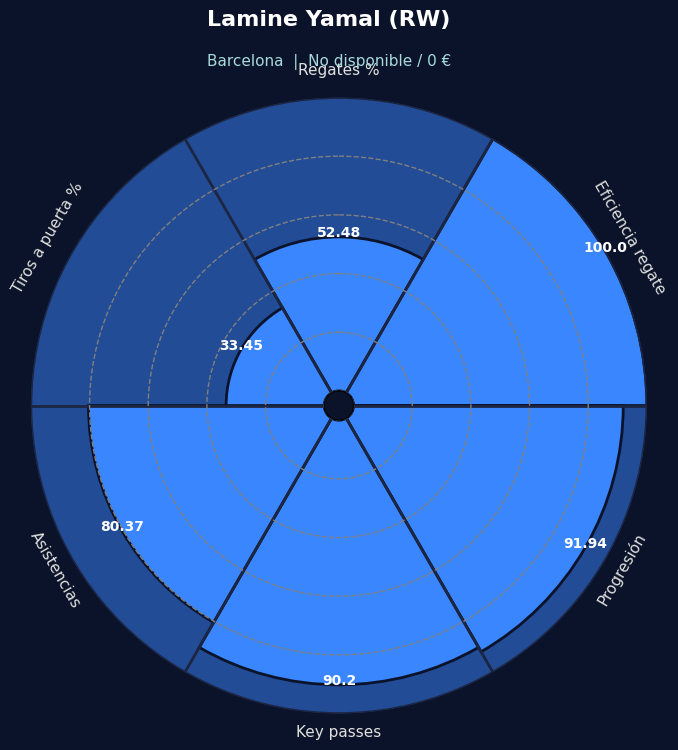

In [83]:
pizza_radar_jugador("Lamine Yamal", df_normalizado, player_stats)

Base de datos

In [84]:
print(len(player_stats.columns))

for column in player_stats.columns:
    print(column)

68
id
name
full_name
age
birth_date
passport_country_names
league
current_team_name
current_team_logo
current_team_color
contract_expires
market_value
market_value_str
minutes_on_field
low_minutes_flag
total_matches
on_loan
main_position
positions_clean
foot
height
weight
goals_avg
non_penalty_goal_avg
head_goals_avg
shots_on_target_percent
shot_efficiency_avg
xg_shot_avg
assists_avg
xg_assist_avg
key_passes_avg
accurate_passes_percent
accurate_pass_avg
accurate_crosses_percent
accurate_crosses_avg
successful_progressive_pass_percent
accurate_progressive_pass_avg
successful_dribbles_percent
dribble_efficiency
progressive_run_avg
real_progression
duels_won
duels_won_avg
offensive_duels_won
defensive_duels_won
aerial_duels_won
aerial_duels_won_avg
successful_defensive_actions_avg
tackle_avg
interceptions_avg
shot_block_avg
conceded_goals_avg
shots_against_avg
save_percent
xg_save_avg
prevented_goals_avg
goalkeeper_exits_avg
gk_aerial_duels_avg
direct_free_kick_taker
direct_free_kicks_on_

In [85]:
print(len(df_normalizado.columns))

for column in df_normalizado.columns:
    print(column)

69
id
name
full_name
age
birth_date
passport_country_names
league
current_team_name
current_team_logo
current_team_color
contract_expires
market_value
market_value_str
minutes_on_field
low_minutes_flag
total_matches
on_loan
main_position
positions_clean
foot
height
weight
direct_free_kick_taker
corner_taker
penalty_taker
player_role
pos_group
goals_avg
non_penalty_goal_avg
head_goals_avg
shots_on_target_percent
shot_efficiency_avg
xg_shot_avg
assists_avg
xg_assist_avg
key_passes_avg
accurate_passes_percent
accurate_pass_avg
accurate_crosses_percent
accurate_crosses_avg
successful_progressive_pass_percent
accurate_progressive_pass_avg
successful_dribbles_percent
dribble_efficiency
progressive_run_avg
real_progression
duels_won
duels_won_avg
offensive_duels_won
defensive_duels_won
aerial_duels_won
aerial_duels_won_avg
successful_defensive_actions_avg
tackle_avg
interceptions_avg
shot_block_avg
conceded_goals_avg
shots_against_avg
save_percent
xg_save_avg
prevented_goals_avg
goalkeeper_ex

In [86]:
profile_cols = [
    "id","name","full_name","age","birth_date",
    "passport_country_names","league","current_team_name",
    "current_team_logo","current_team_color",
    "contract_expires","market_value","market_value_str",
    "on_loan","main_position","positions_clean",
    "player_role","foot","height","weight"
]

df_profile = player_stats[profile_cols]

In [87]:
stats_cols = [
    "id","minutes_on_field","low_minutes_flag","total_matches",
    "goals_avg", "non_penalty_goal_avg", "head_goals_avg", "shots_on_target_percent", "shot_efficiency_avg", "xg_shot_avg", "assists_avg", "xg_assist_avg", "key_passes_avg", "accurate_passes_percent", "accurate_pass_avg", "accurate_crosses_percent", "accurate_crosses_avg", "successful_progressive_pass_percent", "accurate_progressive_pass_avg", "successful_dribbles_percent", "dribble_efficiency", "progressive_run_avg", "real_progression", "duels_won", "duels_won_avg", "offensive_duels_won", "defensive_duels_won", "aerial_duels_won", "aerial_duels_won_avg", "successful_defensive_actions_avg", "tackle_avg", "interceptions_avg", "shot_block_avg", "conceded_goals_avg", "shots_against_avg", "save_percent", "xg_save_avg", "prevented_goals_avg", "goalkeeper_exits_avg", "gk_aerial_duels_avg", "direct_free_kick_taker", "direct_free_kicks_on_target_percent", "corner_taker", "penalty_taker", "penalties_conversion_percent", "fouls_avg", "foul_suffered_avg", "yellow_cards_avg", "red_cards_avg"
]

df_stats = player_stats[stats_cols]

In [88]:
df_norm = df_normalizado.copy()

stats_cols = [
    "id",
    "goals_avg", "non_penalty_goal_avg", "head_goals_avg", "shots_on_target_percent", "shot_efficiency_avg", "xg_shot_avg", "assists_avg", "xg_assist_avg", "key_passes_avg", "accurate_passes_percent", "accurate_pass_avg", "accurate_crosses_percent", "accurate_crosses_avg", "successful_progressive_pass_percent", "accurate_progressive_pass_avg", "successful_dribbles_percent", "dribble_efficiency", "progressive_run_avg", "real_progression", "duels_won", "duels_won_avg", "offensive_duels_won", "defensive_duels_won", "aerial_duels_won", "aerial_duels_won_avg", "successful_defensive_actions_avg", "tackle_avg", "interceptions_avg", "shot_block_avg", "conceded_goals_avg", "shots_against_avg", "save_percent", "xg_save_avg", "prevented_goals_avg", "goalkeeper_exits_avg", "gk_aerial_duels_avg", "direct_free_kick_taker", "direct_free_kicks_on_target_percent", "corner_taker", "penalty_taker", "penalties_conversion_percent", "fouls_avg", "foul_suffered_avg", "yellow_cards_avg", "red_cards_avg"
]

df_filtrado = df_norm[stats_cols]

# renombrar columnas automáticamente
df_norm_filt = df_filtrado.rename(columns=lambda x: x + "_norm" if x != "id" else x)

In [89]:
df_norm_filt

,id,goals_avg_norm,non_penalty_goal_avg_norm,head_goals_avg_norm,shots_on_target_percent_norm,shot_efficiency_avg_norm,xg_shot_avg_norm,assists_avg_norm,xg_assist_avg_norm,key_passes_avg_norm,...,gk_aerial_duels_avg_norm,direct_free_kick_taker_norm,direct_free_kicks_on_target_percent_norm,corner_taker_norm,penalty_taker_norm,penalties_conversion_percent_norm,fouls_avg_norm,foul_suffered_avg_norm,yellow_cards_avg_norm,red_cards_avg_norm
0,-695150,79.27,81.22,28.38,65.21,87.94,51.57,72.33,43.70,90.00,...,NaN,False,29.36,False,False,31.30,46.31,42.97,61.32,32.47
1,-528796,25.63,26.02,28.38,31.45,28.69,45.12,70.40,28.13,38.16,...,NaN,False,29.36,True,False,31.30,44.47,72.99,4.86,79.65
2,-498757,36.40,36.79,73.69,16.35,39.93,46.29,24.49,22.30,32.30,...,NaN,False,29.36,True,False,31.30,15.73,40.62,25.05,32.47
3,-406254,18.98,19.36,28.38,55.61,19.63,42.95,54.10,10.07,13.53,...,NaN,False,29.36,True,False,31.30,22.40,81.15,77.06,86.13
4,-351535,15.01,15.60,69.91,33.15,24.38,30.81,47.38,77.60,57.06,...,NaN,False,29.36,True,False,31.30,52.15,16.16,79.36,32.47
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2548,506249,35.18,35.18,35.18,35.00,65.36,35.00,33.90,33.35,31.88,...,48.10,False,NaN,False,False,35.18,25.28,49.98,14.47,33.16
2549,509149,35.18,35.18,35.18,35.00,65.36,35.00,33.90,33.35,31.88,...,90.42,False,NaN,False,False,35.18,25.28,6.23,64.88,33.16
2550,509793,35.18,35.18,35.18,35.00,65.36,35.00,33.90,33.35,31.88,...,54.31,False,NaN,False,False,35.18,25.28,17.70,57.14,33.16
2551,515401,35.18,35.18,35.18,35.00,65.36,35.00,33.90,33.35,31.88,...,18.50,False,NaN,False,False,35.18,25.28,49.98,57.14,33.16


In [90]:
!pip install sqlalchemy psycopg2-binary

In [91]:
server = '127.0.0.1'
db = 'scout_players_db'
usr = 'postgres'
password = '1234'
port = '5432'

In [92]:
from sqlalchemy import create_engine, text

admin_engine = create_engine(f"postgresql+psycopg2://{usr}:{password}@{server}:{port}/postgres")

with admin_engine.connect() as conn:
    conn.execute(text("COMMIT"))
    conn.execute(text(f"CREATE DATABASE {db}"))

In [93]:

from sqlalchemy import create_engine

pg_engine = create_engine(f"postgresql+psycopg2://{usr}:{password}@{server}:{port}/{db}")

In [94]:
df_profile.to_sql("player_profile", con=pg_engine, if_exists="replace", index=False)
df_stats.to_sql("player_stats", con=pg_engine, if_exists="replace", index=False)
df_norm_filt.to_sql("player_stats_normalized", con=pg_engine, if_exists="replace", index=False)

print("✅ Base de datos creada correctamente")

✅ Base de datos creada correctamente


In [95]:
cols = set(df_profile.columns) | set(df_stats.columns) | set(df_norm_filt.columns)

In [96]:
for col in cols:
    print(col)

goals_avg_norm
corner_taker
accurate_crosses_avg_norm
total_matches
shots_on_target_percent_norm
successful_progressive_pass_percent
aerial_duels_won_avg_norm
main_position
assists_avg
real_progression_norm
name
market_value
birth_date
on_loan
real_progression
prevented_goals_avg
accurate_progressive_pass_avg_norm
gk_aerial_duels_avg
accurate_pass_avg_norm
successful_dribbles_percent_norm
tackle_avg_norm
current_team_logo
low_minutes_flag
shots_against_avg
weight
foot
successful_progressive_pass_percent_norm
corner_taker_norm
save_percent
accurate_progressive_pass_avg
aerial_duels_won
league
market_value_str
aerial_duels_won_norm
non_penalty_goal_avg_norm
full_name
conceded_goals_avg_norm
height
current_team_color
penalty_taker_norm
interceptions_avg_norm
current_team_name
prevented_goals_avg_norm
id
red_cards_avg_norm
penalties_conversion_percent
save_percent_norm
progressive_run_avg
age
offensive_duels_won
xg_save_avg
accurate_crosses_percent_norm
assists_avg_norm
yellow_cards_avg_no